# Transferring of Epithelial cell states from the Gut Cell Atlas (Elementaite, 2021) to Remapped Data Using the `scVI - scANVI` Pipeline

**Developed by:** Anna Maguza\
**Affiliation:** Faculty of Medicine, Würzburg University\
**Creation date:** 6th January 2025\
**Last modified date:** 27th January 2025

#### **Objective**

This notebook outlines the process for transferring epithelial cell states annotations from the Gut Cell Atlas (Elementaite, 2021) to a series of remapped datasets using the `scVI - scANVI` pipeline. Our goal is to ensure consistent annotation of cell types across studies and to identify cells requiring manual validation.\
We analyze the confidence scores produced by `scANVI` to identify cells with low classification certainty. These cells are flagged for potential manual review and validation to ensure the accuracy of the annotations.\
Finally, we evaluate the performance of the `scVI` and `scANVI` models using `scIB` metrics. This step helps quantify the quality of the integration, classification, and batch correction.

## Import packages

In [1]:
import scvi
import torch
import anndata
import warnings
import numpy as np
import scanpy as sc
import anndata
import pandas as pd
import plotnine as p
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scib_metrics.benchmark import Benchmarker

import json
from datetime import datetime

2025-01-27 13:38:32.223362: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-27 13:38:32.223402: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-27 13:38:32.223429: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-27 13:38:32.617109: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## Setup working environment

In [2]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi = 180, color_map = 'magma_r', dpi_save = 300, vector_friendly = True, format = 'svg')

In [3]:
warnings.simplefilter(action = 'ignore')
scvi.settings.seed = 1712
%config InlineBackend.print_figure_kwargs = {'facecolor' : "w"}
%config InlineBackend.figure_format = 'retina'
torch.set_float32_matmul_precision('medium')

Seed set to 1712


In [4]:
arches_params = dict(
    use_layer_norm = "both",
    use_batch_norm = "none",
    encode_covariates = True,
    dropout_rate = 0.2,
    n_layers = 3,
)

In [5]:
def X_is_raw(adata):
    return np.array_equal(adata.X.sum(axis=0).astype(int), adata.X.sum(axis=0))

In [6]:
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')

## Upload data

In [7]:
adata = sc.read_h5ad('integration_of_remapped_data/gut_hs_all_datasets_scVI_scANVI_celltypes_AM_10012025_100142_raw.h5ad')
adata

AnnData object with n_obs × n_vars = 402343 × 43704
    obs: 'cell_id', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_protoc

In [8]:
adata_check = sc.read_h5ad('integration_of_remapped_data/gut_hs_all_datasets_scVI_scANVI_epithelial_cellstates_AM_21012025_224904_raw.h5ad')

In [9]:
adata_check.uns['processing_history']

array(['[E-MTAB-9720] {"step": "create raw anndata after mapping, no filtering", "timestamp": "06112024_121025"}',
       '[E-MTAB-9720] {"timestamp": "27112024_160858", "step": "added qc metrics (generated with sctk), doublets info, filtered cells with less than 100 genes"}',
       '[E-MTAB-9720] {"timestamp": "09122024_103213", "step": "filtered cells based on consensus qc generated with sctk (default parameters), added sex covariates and cell cycle phase"}',
       '[E-MTAB-9720] {"timestamp": "17122024_164056", "step": "Metadata harmonized for integration with other datasets"}',
       '[E-MTAB-9720] {"timestamp": "18122024_124621", "step": "Add metadata clusters using sentence-transformers"}',
       '[E-MTAB-E8901] {"step": "added qc metrics (generated with sctk), doublets info, filtered cells with less than 100 genes", "timestamp": "25112024_121501"}',
       '[E-MTAB-E8901] {"timestamp": "02122024_143702", "step": "filtered cells based on consensus qc generated with sctk (defa

In [10]:
del adata_check

In [11]:
adata.obs['celltype'] = adata.obs['C_scANVI']

In [12]:
adata = adata[adata.obs['celltype'] == 'Epithelial']

In [13]:
adata.obs['Integrated_05'].value_counts()

Integrated_05
Unknown                   85966
Enterocyte                 9780
TA                         7168
Proximal progenitor        4761
Colonocyte                 4170
Stem cells                 2703
Distal progenitor          1471
Goblet cell                1181
BEST4+ epithelial          1112
BEST2+ Goblet cell          711
Paneth                      340
EECs                        167
Progenitor (NEUROG3+)       153
EC cells (TAC1+)            117
Tuft                        102
M/X cells (MLN/GHRL+)        92
I cells (CCK+)               88
CLDN10+ cells                77
Microfold cell               68
D cells (SST+)               55
L cells (PYY+)               37
K cells (GIP+)               37
EC cells (NPW+)              11
N cells (NTS+)                5
Germ                          4
β cells (INS+)                3
Fetal venous EC               1
LTi-like NCR- ILC3            1
Mesoderm 1 (HAND1+)           1
myofibroblast (RSPO2+)        1
Name: count, dtype: int64

In [14]:
del adata.obs['_scvi_batch'], adata.obs['_scvi_labels'], adata.obs['C_scANVI'], adata.obs['confidence_score']
del adata.obsm['X_scANVI'], adata.obsm['X_scVI'], adata.obsm['X_pca'], adata.obsm['umap_uncorrected'], adata.obsm['_scvi_extra_categorical_covs']
del adata.obsm['X_umap_qc']

In [15]:
X_is_raw(adata)

True

## Prepare observations

In [16]:
adata.obs['Protocol REF'] = adata.obs['Protocol REF'].cat.add_categories('Unknown')
adata.obs['Protocol REF'] = adata.obs['Protocol REF'].replace(['  '], 'Unknown')

In [17]:
adata.obs['Protocol REF'].value_counts()

Protocol REF
P-MTAB-95162     46099
P-MTAB-101781    40938
P-MTAB-100978    18267
P-MTAB-102913     8272
P-MTAB-100897     5900
Unknown            907
Name: count, dtype: int64

In [18]:
adata.obs['Performer'].value_counts()

Performer
Wellcome Sanger Institute                                                                            47006
University of Michigan DNA Sequencing core                                                           40938
Wellcome Sanger Institute Cellular Generation and Phenotyping teaml, Kylie James, Rasa Elmentaite    18267
University of Michigan Advanced Genomics Core                                                         8272
Rasa Elmentaite, Kylie James                                                                          5900
Name: count, dtype: int64

In [19]:
adata.obs['library_construction'] = adata.obs['library_construction'].astype(str)
adata.obs['LIBRARY_LAYOUT'] = adata.obs['LIBRARY_LAYOUT'].astype(str)
adata.obs['library_construnction_and_layout'] = adata.obs['library_construction'] + '_' + adata.obs['LIBRARY_LAYOUT']
adata.obs['library_construnction_and_layout'].value_counts()

library_construnction_and_layout
10xV2_PAIRED    71173
10xV2_SINGLE    22830
10xV3_SINGLE    18108
10xV3_PAIRED     8272
Name: count, dtype: int64

In [20]:
adata.obs['donor_id'] = adata.obs['donor_id'].cat.add_categories('cell_culture')
adata.obs['donor_id'] = adata.obs['donor_id'].replace(['nan'], 'cell_culture')

+ Delete samples with less than 10 cells

In [21]:
cell_counts = adata.obs['sample_id'].value_counts()
samples_to_remove = cell_counts[cell_counts < 10].index
adata = adata[~adata.obs['sample_id'].isin(samples_to_remove)].copy()

+ Delete not epithelial cell states 

In [22]:
adata.obs['Integrated_05'].value_counts()

Integrated_05
Unknown                   85960
Enterocyte                 9773
TA                         7165
Proximal progenitor        4760
Colonocyte                 4170
Stem cells                 2697
Distal progenitor          1471
Goblet cell                1181
BEST4+ epithelial          1112
BEST2+ Goblet cell          711
Paneth                      340
EECs                        167
Progenitor (NEUROG3+)       153
EC cells (TAC1+)            117
Tuft                        102
M/X cells (MLN/GHRL+)        92
I cells (CCK+)               88
CLDN10+ cells                77
Microfold cell               68
D cells (SST+)               55
L cells (PYY+)               37
K cells (GIP+)               37
EC cells (NPW+)              11
N cells (NTS+)                5
Germ                          4
β cells (INS+)                3
Fetal venous EC               1
LTi-like NCR- ILC3            1
Mesoderm 1 (HAND1+)           1
myofibroblast (RSPO2+)        1
Name: count, dtype: int64

In [23]:
adata = adata[adata.obs['Integrated_05'] != 'LTi-like NCR- ILC3']
adata = adata[adata.obs['Integrated_05'] != 'Mesoderm 1 (HAND1+)']
adata = adata[adata.obs['Integrated_05'] != 'Fetal venous EC']
adata = adata[adata.obs['Integrated_05'] != 'Germ']
adata = adata[adata.obs['Integrated_05'] != 'myofibroblast (RSPO2+)']

In [24]:
adata.obs['cell_states'] = adata.obs['Integrated_05'].copy()

In [25]:
relabel_mapping = {
    'EECs': 'EEC',
    'Progenitor (NEUROG3+)': 'EEC',
    'EC cells (TAC1+)': 'EEC',
    'M/X cells (MLN/GHRL+)': 'EEC',
    'I cells (CCK+)': 'EEC',
    'D cells (SST+)': 'EEC',
    'K cells (GIP+)': 'EEC',
    'L cells (PYY+)': 'EEC',
    'EC cells (NPW+)': 'EEC',
    'N cells (NTS+)': 'EEC',
    '\u03b2 cells (INS+)': 'EEC',  # Greek letter beta
    'Goblet cell': 'Goblet cell',
    'BEST2+ Goblet cell': 'Goblet cell'
}

In [26]:
cell_type_column = 'cell_states' 
adata.obs[cell_type_column] = adata.obs[cell_type_column].replace(relabel_mapping)
print(adata.obs[cell_type_column].value_counts())


cell_states
Unknown                85960
Enterocyte              9773
TA                      7165
Proximal progenitor     4760
Colonocyte              4170
Stem cells              2697
Goblet cell             1892
Distal progenitor       1471
BEST4+ epithelial       1112
EEC                      765
Paneth                   340
Tuft                     102
CLDN10+ cells             77
Microfold cell            68
Name: count, dtype: int64


+ Delete doublets

In [27]:
adata = adata[adata.obs['predicted_doublets'] != 'True']

+ Fix issue with Boolean None

In [28]:
nan_summary = adata.obs.isna().sum()

print(nan_summary[nan_summary > 0])

cell_type               46328
time                   101833
qc_cluster              18192
cluster_passed_qc       18192
consensus_fraction      18192
consensus_passed_qc     18192
gestational_age         72792
passage                 72792
batch                   48707
sampling_site          104212
dtype: int64


In [29]:
nan_info = nan_summary[nan_summary > 0].to_frame(name='NaN Count')
nan_info['Data Type'] = adata.obs.dtypes[nan_summary > 0]

print(nan_info)

                     NaN Count Data Type
cell_type                46328  category
time                    101833   float64
qc_cluster               18192  category
cluster_passed_qc        18192   boolean
consensus_fraction       18192   float64
consensus_passed_qc      18192   boolean
gestational_age          72792  category
passage                  72792  category
batch                    48707  category
sampling_site           104212  category


In [30]:
adata.obs['cell_type'] = adata.obs['cell_type'].replace(['  '], 'unsorted')
adata.obs['cell_type'] = adata.obs['cell_type'].replace(['epithelial cell'], 'intestinal epithelial cell')
adata.obs['cell_type'] = adata.obs['cell_type'].cat.remove_unused_categories()
adata.obs['cell_type'] = adata.obs['cell_type'].fillna('unsorted')
adata.obs['cell_type'].value_counts()

cell_type
unsorted                      63834
intestinal epithelial cell    32447
CD45 negative                  8130
CD45 positive                  5694
Name: count, dtype: int64

In [31]:
adata.obs['cluster_passed_qc'] = adata.obs['cluster_passed_qc'].astype(str)
adata.obs['cluster_passed_qc'] = adata.obs['cluster_passed_qc'].fillna('N/A')
adata.obs['consensus_fraction'] = adata.obs['consensus_fraction'].astype(str)
adata.obs['consensus_fraction'] = adata.obs['consensus_fraction'].fillna('N/A')
adata.obs['consensus_passed_qc'] = adata.obs['consensus_passed_qc'].astype(str)
adata.obs['consensus_passed_qc'] = adata.obs['consensus_passed_qc'].fillna('N/A')
adata.obs['qc_cluster'] = adata.obs['qc_cluster'].astype(str)
adata.obs['qc_cluster'] = adata.obs['qc_cluster'].fillna('N/A')

In [32]:
adata.obs['gestational_age'] = adata.obs['gestational_age'].cat.add_categories('N/A - not fetal')
adata.obs['gestational_age'] = adata.obs['gestational_age'].replace(['  '], 'N/A - not fetal')
adata.obs['gestational_age'] = adata.obs['gestational_age'].fillna('N/A - not fetal')
adata.obs['gestational_age'].value_counts()

gestational_age
N/A - not fetal    73699
11.9                6597
11.2                6082
12.2                5399
8.5                 5232
7.4                 3090
9.9                 2860
8.4                 2700
8.7                 1835
8.9                 1402
10.4                1030
8.1                  179
Name: count, dtype: int64

In [33]:
adata.obs['passage'] = adata.obs['passage'].cat.add_categories('N/A')
adata.obs['passage'] = adata.obs['passage'].replace(['  '], 'N/A')
adata.obs['passage'] = adata.obs['passage'].fillna('N/A')
adata.obs['passage'].value_counts()

passage
N/A    99083
2       5232
17      3090
1       2700
Name: count, dtype: int64

In [34]:
adata.obs['batch'] = adata.obs['batch'].cat.add_categories('unknown')
adata.obs['batch'] = adata.obs['batch'].fillna('unknown')

In [35]:
adata.obs['sampling_site'] = adata.obs['sampling_site'].cat.add_categories('unknown')
adata.obs['sampling_site'] = adata.obs['sampling_site'].replace(['  '], 'unknown')
adata.obs['sampling_site'] = adata.obs['sampling_site'].fillna('unknown')
adata.obs['sampling_site'].value_counts()

sampling_site
unknown     105261
middle        1758
terminal      1695
proximal      1391
Name: count, dtype: int64

In [36]:
nan_summary = adata.obs.isna().sum()

print(nan_summary[nan_summary > 0])

time    101833
dtype: int64


## Visualize uncorrected dataset

In [37]:
adata_log = adata.copy()
sc.pp.normalize_total(adata_log, target_sum=1e6, exclude_highly_expressed=True)
sc.pp.log1p(adata_log)

normalizing counts per cell. The following highly-expressed genes are not considered during normalization factor computation:
['PLA2G2A', 'GUCA2B', 'GUCA2A', 'CLCA1', 'ATP1A1-AS1', 'REG4', 'S100A6', 'ITLN1', 'ITLN2', 'APOA2', 'PIGR', 'REG1A', 'REG3A', 'FABP1', 'GCG', 'CRYBA2', 'GHRL', 'CCK', 'RBP2', 'SST', 'ENSG00000286848', 'JCHAIN', 'GC', 'ALB', 'AFP', 'RPL34', 'CCDC152', 'ATG10', 'SPINK1', 'FABP6', 'ENSG00000271581', 'MLN', 'ENSG00000287089', 'CLPS', 'AGR2', 'RPL30-AS1', 'RPS6', 'SPINK4', 'RPL12', 'LCN2', 'LCN15', 'VIM-AS1', 'ADIRF-AS1', 'SHLD2', 'INS', 'BEST1', 'FTH1', 'TALAM1', 'ENSG00000285513', 'APOA4', 'APOC3', 'APOA1', 'APOA1-AS', 'GAPDH', 'ENSG00000269968', 'MRPS35-DT', 'LYZ', 'ENSG00000257764', 'NTS', 'TPT1', 'ENSG00000273149', 'CKB', 'PHGR1', 'ENSG00000290038', 'ENSG00000290010', 'ZG16', 'MT2A', 'MT1G', 'MT1H', 'GAST', 'PYY', 'GIP', 'TTR', 'ENSG00000267598', 'YIF1B', 'RPS19', 'FTL', 'TFF3', 'TFF2', 'TFF1', 'IGLC2', 'IGLC3', 'TMSB4X', 'PCSK1N', 'MT-RNR1', 'MT-RNR2', 'MT-CO1'

In [38]:
sc.pp.pca(adata_log)

computing PCA
    with n_comps=50
    finished (0:00:51)


In [39]:
sc.pp.neighbors(adata_log, n_neighbors=15, n_pcs=50)
sc.tl.umap(adata_log)

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:30)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:01:43)


In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.set_figure_params(figsize=(10,10))
    sc.pl.pca(adata_log,color=["Study_name", "ArrayExpress_ID", 'disease', 'organism_part', 'developmental_stage', 'library_preparation_protocol', 'age_group', 'immunophenotype', 'category', 'sex', 'Cell_cycle_phase', 'metadata_cluster', 'growth_condition'], ncols=4, frameon=False, show=False)
    plt.savefig(f"integration_of_remapped_data/plots/epithelial_uncorrected_PCA_categorical_values.png", bbox_inches="tight")

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.set_figure_params(figsize=(10,10))
    sc.pl.pca(adata_log,color=['n_genes', 'predicted_doublets', 'n_counts', 'percent_mito', 'percent_ribo', 'percent_hb', 'total_counts', 'n_genes_by_counts'], color_map = 'magma_r', ncols=4, frameon=False, show=False)
    plt.savefig(f"integration_of_remapped_data/plots/epithelial_uncorrected_PCA_continious_values.png", bbox_inches="tight")

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.set_figure_params(figsize=(10,10))
    sc.pl.umap(adata_log,color=["Study_name", "ArrayExpress_ID", 'disease', 'organism_part', 'developmental_stage', 'library_preparation_protocol', 'age_group', 'immunophenotype', 'category', 'sex', 'Cell_cycle_phase', 'metadata_cluster', 'growth_condition'], ncols=4, frameon=False, show=False)
    plt.savefig(f"integration_of_remapped_data/plots/epithelial_uncorrected_umap_categorical_values.png", bbox_inches="tight")

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.set_figure_params(figsize=(10,10))
    sc.pl.umap(adata_log,color=['n_genes', 'predicted_doublets', 'n_counts', 'percent_mito', 'percent_ribo', 'percent_hb', 'total_counts', 'n_genes_by_counts'], color_map = 'magma_r', ncols=4, frameon=False, show=False)
    plt.savefig(f"integration_of_remapped_data/plots/epithelial_uncorrected_umap_continious_values.png", bbox_inches="tight")

In [44]:
adata.obsm['X_pca'] = adata_log.obsm['X_pca'].copy()
adata.obsm['umap_uncorrected'] = adata_log.obsm['X_umap'].copy()

In [45]:
del adata_log

In [46]:
adata_raw = adata.copy()

## Extract highly variable genes

We extract the highly variable genes from the old reference dataset.

In [47]:
adata_ref = sc.read_h5ad('Healthy_reference/Integrated/Integrated_4_datasets_05042024.h5ad')

In [48]:
adata_ref.layers["counts"] = adata_ref.X.copy()

In [49]:
sc.pp.highly_variable_genes(
    adata_ref,
    flavor = "seurat_v3",
    n_top_genes = 7000,
    layer = "counts",
    batch_key = "Library_Preparation_Protocol",
    subset = True,
    span = 1
)

extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'variances_norm', float vector (adata.var)


In [50]:
genes_to_keep = adata_ref.var_names.intersection(adata.var_names)
adata = adata[:, genes_to_keep].copy()

In [51]:
adata

AnnData object with n_obs × n_vars = 110105 × 5062
    obs: 'cell_id', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_protoco

In [52]:
del adata_ref

## Run scVI

In [53]:
adata.layers['counts'] = adata.X.copy()

In [54]:
scvi.model.SCVI.setup_anndata(adata, 
                              categorical_covariate_keys=['sample_id', 'library_construnction_and_layout', 'Performer', 'Protocol REF'],
                              labels_key = "cell_states", 
                              layer = 'counts')

In [55]:
scvi_model = scvi.model.SCVI(adata,
                            n_latent = 150, 
                            n_hidden = 256,
                            n_layers = 3, 
                            dropout_rate = 0.1,
                            dispersion = 'gene-cell', 
                            gene_likelihood = 'nb')

In [56]:
scvi_model.train(300, 
                early_stopping = True,
                early_stopping_patience = 10,
                check_val_every_n_epoch = 1, 
                enable_progress_bar = True, 
                accelerator = "gpu",
                devices = [1])

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Training:   0%|          | 0/300 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 10 records. Best score: 1295.788. Signaling Trainer to stop.


In [57]:
adata.obsm["X_scVI"] = scvi_model.get_latent_representation(adata)

#### Evaluate model performance using the [_Svensson_](https://www.nxn.se/valent/2023/8/10/training-scvi-posterior-predictive-distributions-over-epochs) method

In [58]:
history_df = (
    scvi_model.history['elbo_train'].astype(float)
    .join(scvi_model.history['elbo_validation'].astype(float))
    .reset_index()
    .melt(id_vars=['epoch'])
)

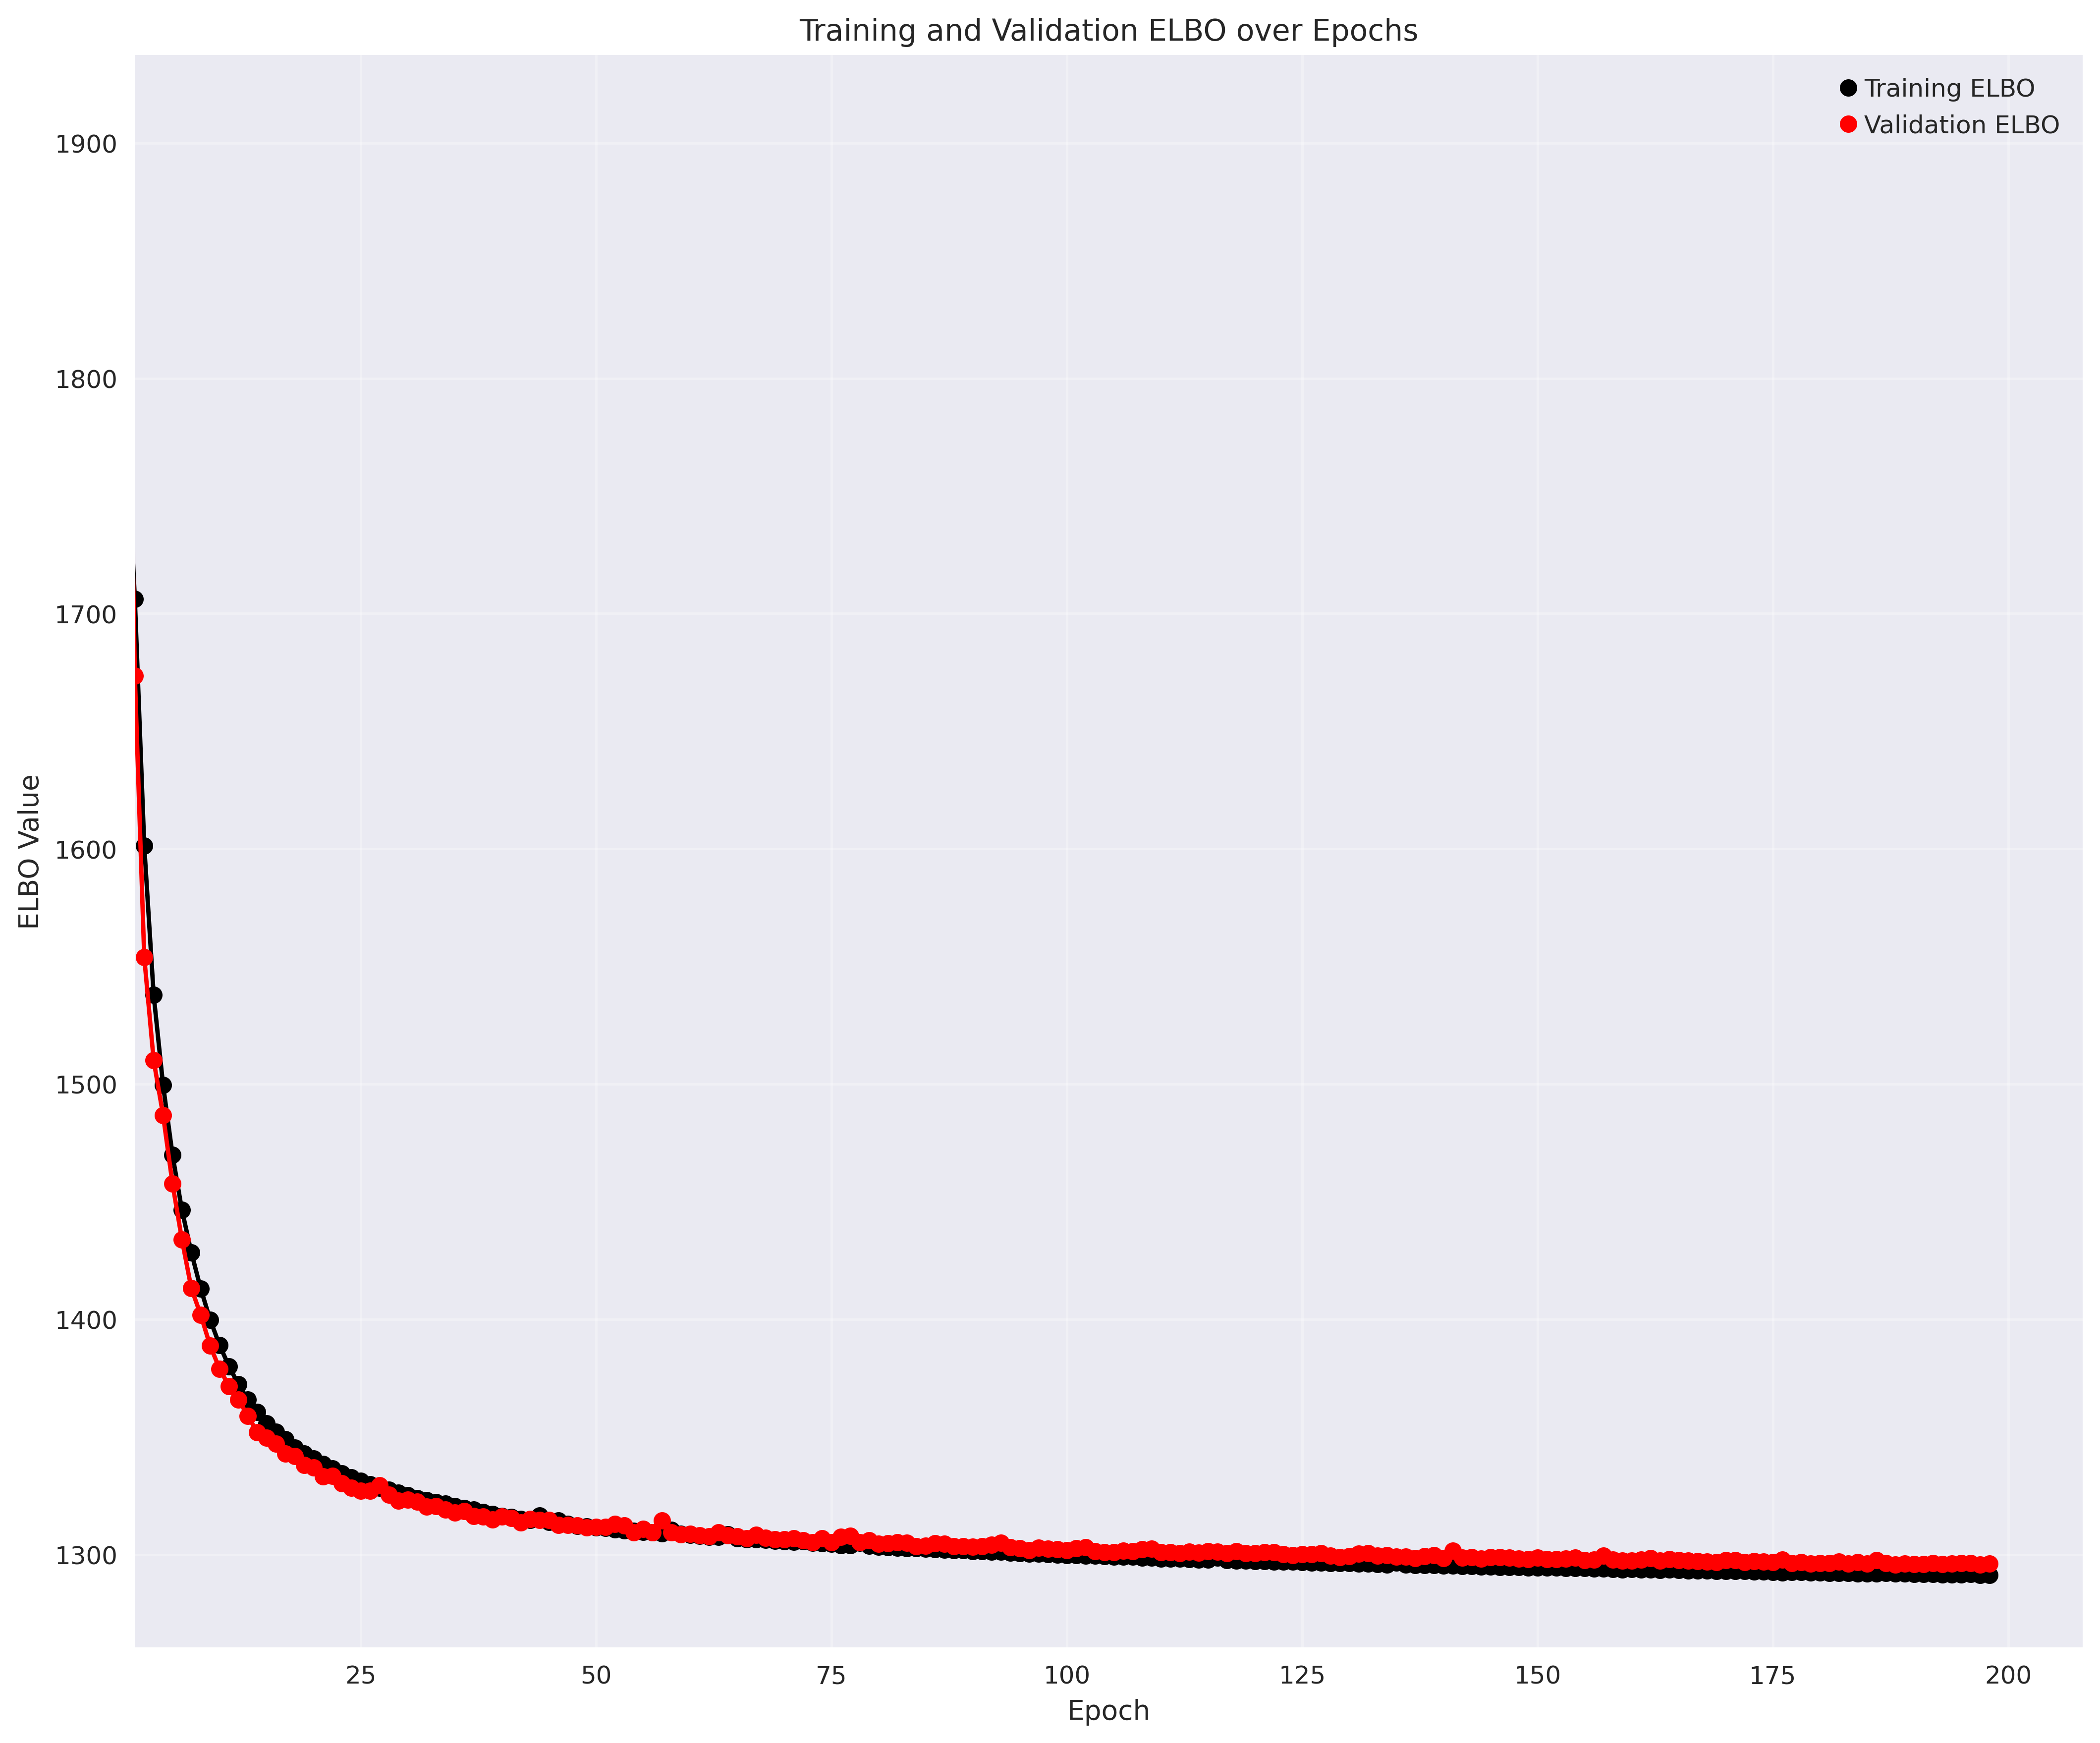

In [59]:
plt.style.use('seaborn')
plt.figure(figsize=(12, 10))

plt.plot(history_df[history_df['variable'] == 'elbo_train']['epoch'], 
         history_df[history_df['variable'] == 'elbo_train']['value'], 
         color='black', marker='o', label='Training ELBO')

plt.plot(history_df[history_df['variable'] == 'elbo_validation']['epoch'],
         history_df[history_df['variable'] == 'elbo_validation']['value'], 
         color='red', marker='o', label='Validation ELBO')

plt.xlabel('Epoch')
plt.ylabel('ELBO Value')
plt.title('Training and Validation ELBO over Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.xlim(left=1)

plt.tight_layout()
plt.show()

#plt.savefig(f'integration_of_remapped_data/epithelial_scvi_model_{timestamp}/scvi_cell_types_elbo.png', dpi=300, bbox_inches='tight')

#### Label transfer with `scANVI` 

In [65]:
scanvi_model = scvi.model.SCANVI.from_scvi_model(scvi_model, 'Unknown')

In [66]:
scanvi_model.train(300, 
                     early_stopping = True,
                   check_val_every_n_epoch = 1, 
                   enable_progress_bar = True,
                   accelerator = "gpu",
                   devices = [0])

INFO     Training for 300 epochs.                                                                                  


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Training:   0%|          | 0/300 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=300` reached.


In [67]:
adata.obs["cellstates_scANVI"] = scanvi_model.predict(adata)

- Extract latent representation

In [68]:
adata.obsm["X_scANVI"] = scanvi_model.get_latent_representation(adata)

### Explore model performance using the [_Svensson_](https://www.nxn.se/valent/2023/8/10/training-scvi-posterior-predictive-distributions-over-epochs) method

In [69]:
history_df = (
    scanvi_model.history['elbo_train'].astype(float)
    .join(scanvi_model.history['elbo_validation'].astype(float))
    .reset_index()
    .melt(id_vars = ['epoch'])
)

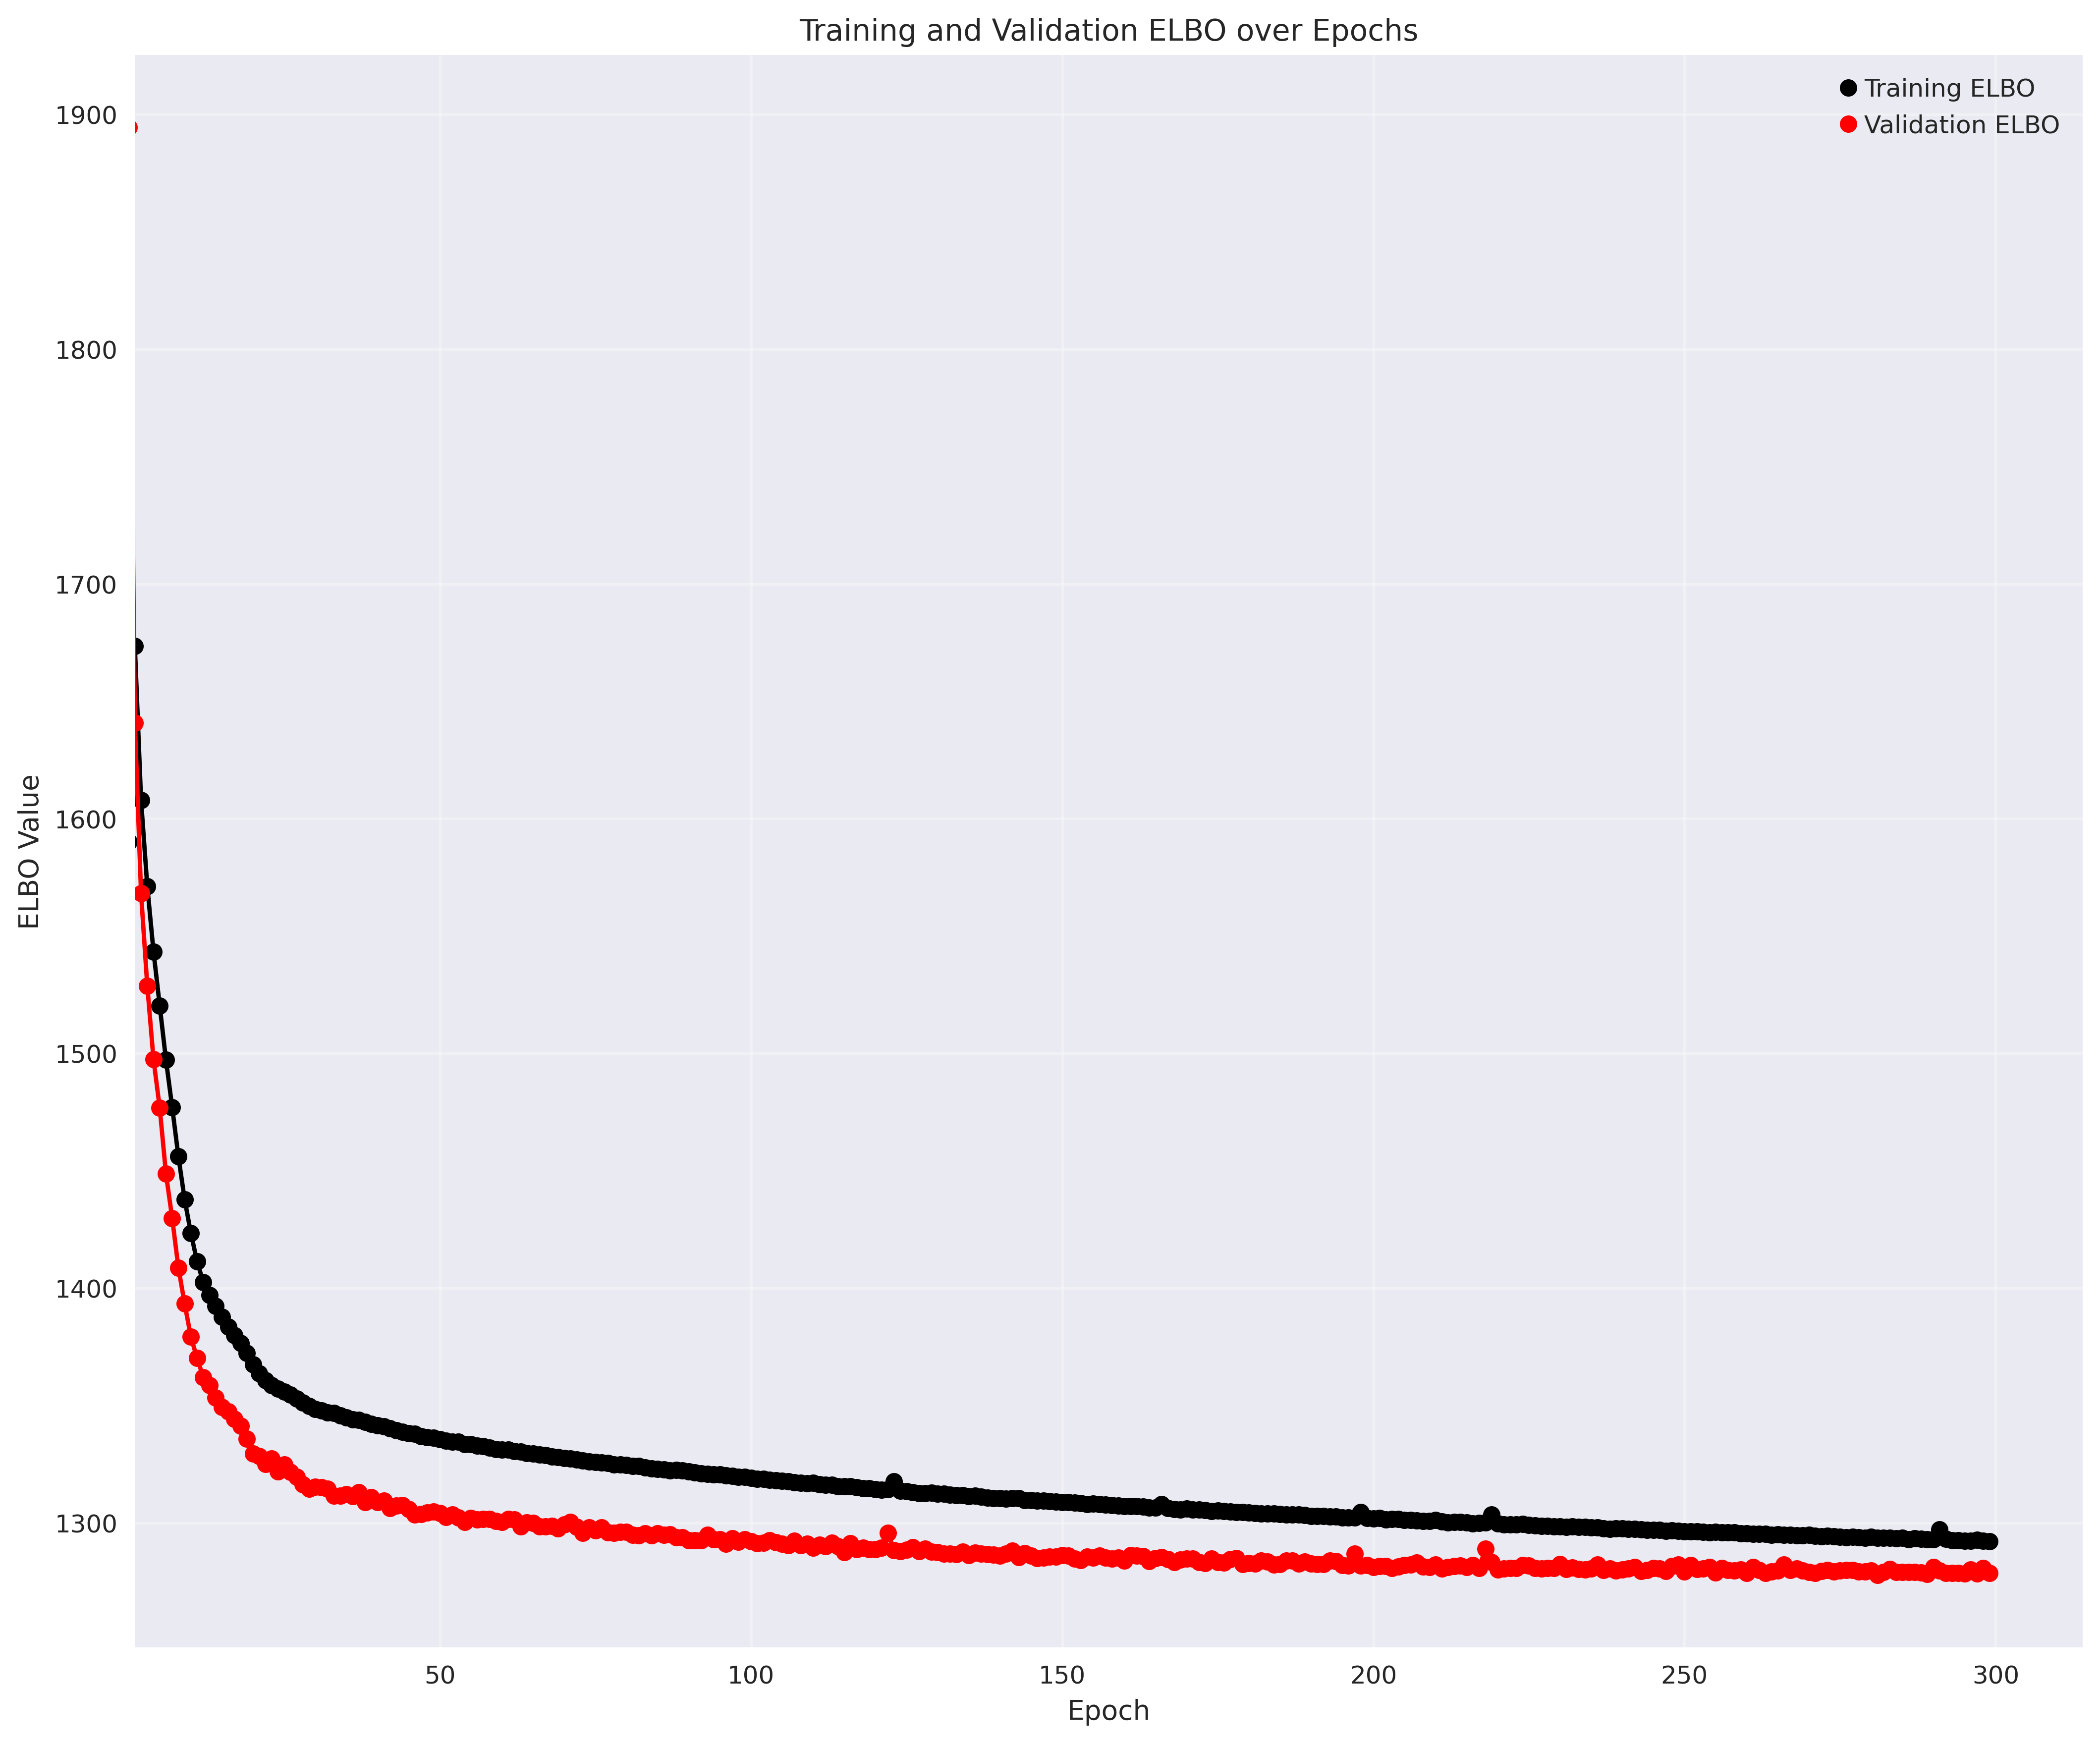

In [70]:
plt.style.use('seaborn')
plt.figure(figsize=(12, 10))

plt.plot(history_df[history_df['variable'] == 'elbo_train']['epoch'], 
         history_df[history_df['variable'] == 'elbo_train']['value'], 
         color='black', marker='o', label='Training ELBO')

plt.plot(history_df[history_df['variable'] == 'elbo_validation']['epoch'],
         history_df[history_df['variable'] == 'elbo_validation']['value'], 
         color='red', marker='o', label='Validation ELBO')

plt.xlabel('Epoch')
plt.ylabel('ELBO Value')
plt.title('Training and Validation ELBO over Epochs')
plt.legend()
plt.grid(True, alpha=0.3)

plt.xlim(left=1)

plt.tight_layout()
plt.show()

#plt.savefig(f'integration_of_remapped_data/epithelial_scanvi_model_{timestamp}/scanvi_cell_types_elbo.png', dpi=300, bbox_inches='tight')

In [71]:
posterior_probs = scanvi_model.predict(adata, soft=True)

In [72]:
confidence_scores = posterior_probs.max(axis=1)

In [73]:
adata.obs['confidence_score'] = confidence_scores

+ Visualize dataset

In [74]:
sc.pp.neighbors(adata, use_rep = "X_scANVI", n_neighbors = 150, metric = 'minkowski')
sc.tl.umap(adata, min_dist = 0.6, spread = 8, random_state = 1712)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:02:51)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:01:19)


In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=["cellstates_scANVI", "confidence_score", 'cell_states', 'Integrated_05'], ncols=4, color_map = 'magma_r', frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/epithelial_cellstates_transfer_scANVI_values_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=["Study_name", "ArrayExpress_ID", 'metadata_cluster', 'age_group'], ncols=4, frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/epithelial_cellstates_transfer_categorical_values1_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=['organism_part', 'developmental_stage', 'library_preparation_protocol', 'immunophenotype'], ncols=2, frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/epithelial_cellstates_transfer_categorical_values2_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=['sex', 'Cell_cycle_phase', 'developmental_stage', 'full_age', 'growth_condition'], ncols=3, frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/epithelial_cellstates_transfer_categorical_values3_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=['sampling_site', 'Material Type', 'donor_id'], ncols=3, frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/epithelial_cellstates_transfer_categorical_values4_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=['library_construnction_and_layout', 'Protocol REF', 'Performer'], ncols=3, frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/epithelial_cellstates_transfer_categorical_values5_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=['n_genes', 'n_counts', 'total_counts', 'n_genes_by_counts'], color_map = 'magma_r', ncols=4, frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/epithelial_cellstates_transfer_continious_values1_{timestamp}.png", bbox_inches="tight")
    plt.show()

In [ ]:
with plt.rc_context():
    sc.set_figure_params(dpi=300, figsize=(15, 15))
    sc.pl.umap(adata,color=['predicted_doublets', 'percent_mito', 'percent_ribo', 'percent_hb'], color_map = 'magma_r', ncols=4, frameon=False, show=False, size = 3)
    plt.savefig(f"integration_of_remapped_data/plots/epithelial_cellstates_transfer_continious2_values_{timestamp}.png", bbox_inches="tight")
    plt.show()

## Save prepared dataset

In [75]:
adata_export= adata_raw.copy()
adata_export

AnnData object with n_obs × n_vars = 110105 × 43704
    obs: 'cell_id', 'Source Name', 'ENA_SAMPLE', 'BioSD_SAMPLE', 'organism', 'disease', 'organism_part', 'cell_type', 'growth_condition', 'developmental_stage', 'Material Type', 'Protocol REF', 'sample_id', 'LIBRARY_LAYOUT', 'cdna_read_size', 'cell_barcode_size', 'end_bias', 'library_construction', 'sample_barcode_size', 'umi_barcode_offset', 'umi_barcode_size', 'Performer', 'Assay Name', 'ENA_EXPERIMENT', 'ENA_RUN', 'time', 'time_unit', 'n_genes', 'doublet_scores', 'predicted_doublets', 'n_counts', 'log1p_n_counts', 'log1p_n_genes', 'percent_mito', 'n_counts_mito', 'percent_ribo', 'n_counts_ribo', 'percent_hb', 'n_counts_hb', 'percent_top50', 'cell_passed_qc', 'qc_cluster', 'cluster_passed_qc', 'consensus_fraction', 'consensus_passed_qc', 'total_counts', 'n_genes_by_counts', 'percent_chrY', 'XIST-counts', 'XIST-percentage', 'sex', 'S_score', 'G2M_score', 'Cell_cycle_phase', 'Study_name', 'ArrayExpress_ID', 'library_preparation_protoc

In [76]:
adata_export.obs['cellstates_scANVI'] = adata.obs['cellstates_scANVI'].copy()
adata_export.obs['confidence_score'] = adata.obs['confidence_score'].copy()
adata_export.obsm['X_scVI'] = adata.obsm['X_scVI'].copy()
adata_export.obsm['X_scANVI'] = adata.obsm['X_scANVI'].copy()
adata_export.obsm['X_pca'] = adata.obsm['X_pca'].copy()
adata_export.obsm['umap_uncorrected'] = adata.obsm['umap_uncorrected'].copy()
adata_export.obsm['X_umap'] = adata.obsm['X_umap'].copy()

In [77]:
current_history = adata_export.uns['processing_history'].tolist()

new_entry = json.dumps({
    'timestamp': timestamp,
    'step': 'Extracted genes (7000, library_preparation_protocol - batch) that were previously captured as highly variable, merged EEC smaller populations into one group, fixed bolean nan issue, deleted samples with less than 10 cells, deleted doublets, predicted epithelial cell states using scVI-scANVI, scvi params: batch = sample_id, library_construnction_and_layout,Performer and Protocol REF, n_latent = 150, n_hidden = 256, n_layers = 3, dropout_rate = 0.1, dispersion = gene-cell, gene_likelihood = nb, 152 epochs, scanvi params: 462 epochs, concatenated small EECs substates into one group, predicted epithelial cell states using scVI-scANVI, scvi params: batch = sample_id, library_construnction_and_layout,Performer and Protocol REF, n_latent = 150, n_hidden = 256, n_layers = 3, dropout_rate = 0.1, dispersion = gene-cell, gene_likelihood = nb, 20 epochs, scanvi params: 300 epochs',
})
current_history.append(new_entry)

adata_export.uns['processing_history'] = current_history

In [78]:
project = 'gut'
species = 'hs'
name = 'AM'
counts = 'raw'
atribute = 'all_datasets_scVI_scANVI_epithelial_cellstates'

adata_export.write_h5ad(f"integration_of_remapped_data/{project}_{species}_{atribute}_{name}_{timestamp}_{counts}.h5ad")

In [79]:
adata.obs["cellstates_scANVI"].value_counts()

cellstates_scANVI
Enterocyte             28766
Proximal progenitor    26304
TA                     14501
Stem cells             13495
Colonocyte             11417
BEST4+ epithelial       6008
Goblet cell             5621
EEC                     3516
Distal progenitor        249
Tuft                     215
Paneth                    13
Name: count, dtype: int64

In [89]:
timestamp

'27012025_133833'